<a href="https://colab.research.google.com/github/BusyWomen/IoT-Arduino/blob/main/A_B_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ab_test_data.csv')
display(df.head())

,user_id,group,device,traffic_source,age_group,session_duration_seconds,pages_viewed,converted
0,100001,Control,Mobile,Social,45-54,141.8,6.0,0.0
1,100002,Treatment,Mobile,Paid Search,25-34,128.7,5.0,0.0
2,100003,Control,Mobile,Referral,25-34,310.0,7.0,0.0
3,100004,Control,Mobile,Organic,35-44,447.4,3.0,1.0
4,100005,Control,Mobile,Paid Search,25-34,117.0,10.0,0.0


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4121
Columns: 8


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4121 entries, 0 to 4120
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   4121 non-null   int64  
 1   group                     4121 non-null   object 
 2   device                    4121 non-null   object 
 3   traffic_source            4121 non-null   object 
 4   age_group                 4120 non-null   object 
 5   session_duration_seconds  4120 non-null   float64
 6   pages_viewed              4120 non-null   float64
 7   converted                 4120 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 257.7+ KB


In [ ]:
df.isnull().sum()

,0
user_id,0
group,0
device,0
traffic_source,0
age_group,1
session_duration_seconds,1
pages_viewed,1
converted,1


In [ ]:
df["user_id"].duplicated().sum()

np.int64(0)

In [ ]:
df["group"].value_counts()

,count
group,
Treatment,2070
Control,2051


In [ ]:
df.dropna(inplace=True)
df.isnull().sum()

,0
user_id,0
group,0
device,0
traffic_source,0
age_group,0
session_duration_seconds,0
pages_viewed,0
converted,0


In [ ]:
conversion_summary = (
        df.groupby("group")["converted"]
              .agg(["count", "sum", "mean"])
)

conversion_summary.columns = [
        "visitors",
            "conversions",
                "conversion_rate"
]

conversion_summary["conversion_rate"] *= 100

display(conversion_summary)

,visitors,conversions,conversion_rate
group,,,
Control,2051,198.0,9.653827
Treatment,2069,244.0,11.793137


In [ ]:
control_rate = conversion_summary.loc["Control", "conversion_rate"]
treatment_rate = conversion_summary.loc["Treatment", "conversion_rate"]

absolute_lift = treatment_rate - control_rate

relative_lift = (
        (treatment_rate - control_rate) / control_rate
) * 100

print(f"Control conversion rate: {control_rate:.2f}%")
print(f"Treatment conversion rate: {treatment_rate:.2f}%")
print(f"Absolute lift: {absolute_lift:.2f} percentage points")
print(f"Relative lift: {relative_lift:.2f}%")

Control conversion rate: 9.65%
Treatment conversion rate: 11.79%
Absolute lift: 2.14 percentage points
Relative lift: 22.16%


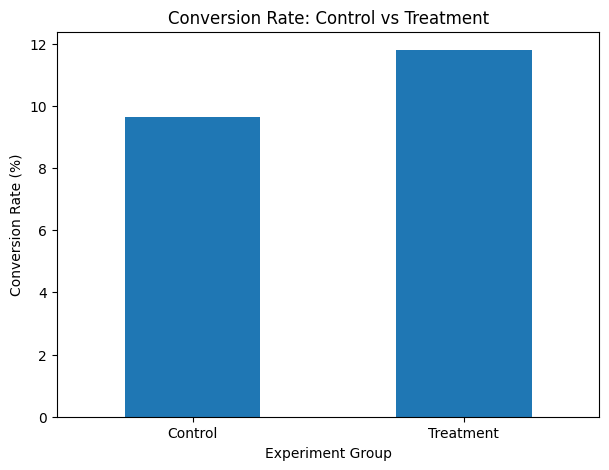

In [ ]:
rates = df.groupby("group")["converted"].mean() * 100

plt.figure(figsize=(7, 5))
rates.plot(kind="bar")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Experiment Group")
plt.title("Conversion Rate: Control vs Treatment")
plt.xticks(rotation=0)
plt.show()

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Number of conversions in each group
conversions = np.array([
        df.loc[df["group"] == "Control", "converted"].sum(),
            df.loc[df["group"] == "Treatment", "converted"].sum()
])

# Number of users in each group
sample_sizes = np.array([
        (df["group"] == "Control").sum(),
            (df["group"] == "Treatment").sum()
])

# Two-proportion z-test
z_stat, p_value = proportions_ztest(
        count=conversions,
            nobs=sample_sizes
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -2.2185452020812124
P-value: 0.02651768112502999


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("The difference in conversion rates is statistically significant.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that conversion rates differ.")

Reject the null hypothesis.
The difference in conversion rates is statistically significant.


In [ ]:
from statsmodels.stats.proportion import confint_proportions_2indep

control_conversions = df.loc[
        df["group"] == "Control", "converted"
].sum()

control_users = (
        df["group"] == "Control"
).sum()

treatment_conversions = df.loc[
        df["group"] == "Treatment", "converted"
].sum()

treatment_users = (
        df["group"] == "Treatment"
).sum()

ci_low, ci_high = confint_proportions_2indep(
        treatment_conversions,
            treatment_users,
                control_conversions,
                    control_users,
                        method="wald"
)

print(f"95% CI: {ci_low:.4f} to {ci_high:.4f}")

95% CI: 0.0025 to 0.0403


In [ ]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# Number of conversions
conversions = np.array([
        df.loc[df["group"] == "Control", "converted"].sum(),
            df.loc[df["group"] == "Treatment", "converted"].sum()
])

# Number of users
sample_sizes = np.array([
        (df["group"] == "Control").sum(),
            (df["group"] == "Treatment").sum()
])

# Two-proportion z-test
z_stat, p_value = proportions_ztest(
        count=conversions,
            nobs=sample_sizes
)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

Z-statistic: -2.2185
P-value: 0.026518


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

def run_ab_test(data, segment_column, segment_value):
    segment = data[data[segment_column] == segment_value]

    control = segment[segment["group"] == "Control"]["converted"]
    treatment = segment[segment["group"] == "Treatment"]["converted"]

    conversions = np.array([
        control.sum(),
        treatment.sum()
    ])

    sample_sizes = np.array([
        len(control),
        len(treatment)
    ])

    z_stat, p_value = proportions_ztest(
        conversions,
        sample_sizes
    )

    control_rate = control.mean()
    treatment_rate = treatment.mean()

    absolute_lift = treatment_rate - control_rate

    return {
        "Segment": segment_value,
        "Control Rate": control_rate,
        "Treatment Rate": treatment_rate,
        "Absolute Lift": absolute_lift,
        "Z-statistic": z_stat,
        "P-value": p_value
    }

In [ ]:
device_tests = []

for device in df["device"].unique():
    result = run_ab_test(
        df,
        "device",
        device
    )
    device_tests.append(result)

device_test_results = pd.DataFrame(device_tests)

In [ ]:
device_test_results["Control Rate"] = (
    device_test_results["Control Rate"] * 100
).round(2)

device_test_results["Treatment Rate"] = (
    device_test_results["Treatment Rate"] * 100
).round(2)

device_test_results["Absolute Lift"] = (
    device_test_results["Absolute Lift"] * 100
).round(2)

device_test_results["P-value"] = (
    device_test_results["P-value"]
).round(4)

display(device_test_results)

,Segment,Control Rate,Treatment Rate,Absolute Lift,Z-statistic,P-value
0,Mobile,8.07,10.42,2.35,-2.052868,0.0401
1,Desktop,13.04,14.10,1.06,-0.536945,0.5913
2,Tablet,10.16,13.66,3.50,-1.010991,0.3120


In [ ]:
traffic_source_tests = []

for source in df["traffic_source"].unique():
    result = run_ab_test(
        df,
        "traffic_source",
        source
    )
    traffic_source_tests.append(result)

traffic_source_test_results = pd.DataFrame(traffic_source_tests)

In [ ]:
traffic_source_test_results["Control Rate"] = (
    traffic_source_test_results["Control Rate"] * 100
).round(2)

traffic_source_test_results["Treatment Rate"] = (
    traffic_source_test_results["Treatment Rate"] * 100
).round(2)

traffic_source_test_results["Absolute Lift"] = (
    traffic_source_test_results["Absolute Lift"] * 100
).round(2)

traffic_source_test_results["P-value"] = (
    traffic_source_test_results["P-value"]
).round(4)

display(traffic_source_test_results)

,Segment,Control Rate,Treatment Rate,Absolute Lift,Z-statistic,P-value
0,Social,7.87,10.37,2.50,-1.194083,0.2324
1,Paid Search,8.28,10.04,1.76,-0.953952,0.3401
2,Referral,10.71,10.63,-0.09,0.028979,0.9769
3,Organic,10.64,12.94,2.31,-1.365646,0.1721
4,Email,11.30,14.96,3.66,-1.201611,0.2295


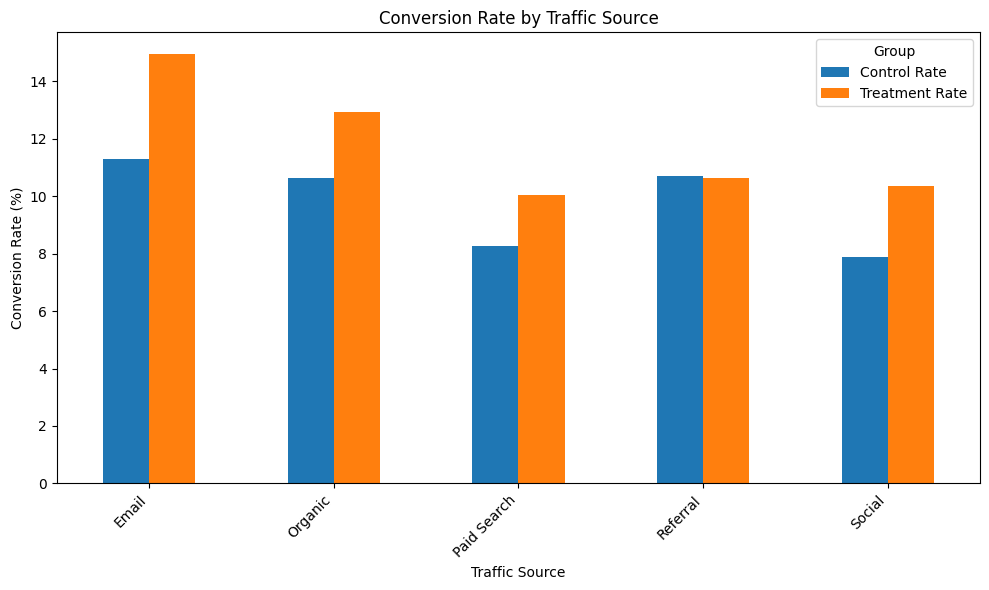

In [ ]:
traffic_source_pivot = (
    traffic_source_test_results
    .pivot_table(index="Segment", values=["Control Rate", "Treatment Rate"])
)

traffic_source_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Conversion Rate by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Group")
plt.tight_layout()
plt.show()

In [ ]:
age_group_tests = []

for age_group in df["age_group"].unique():
    result = run_ab_test(
        df,
        "age_group",
        age_group
    )
    age_group_tests.append(result)

age_group_test_results = pd.DataFrame(age_group_tests)

In [ ]:
age_group_test_results["Control Rate"] = (
    age_group_test_results["Control Rate"] * 100
).round(2)

age_group_test_results["Treatment Rate"] = (
    age_group_test_results["Treatment Rate"] * 100
).round(2)

age_group_test_results["Absolute Lift"] = (
    age_group_test_results["Absolute Lift"] * 100
).round(2)

age_group_test_results["P-value"] = (
    age_group_test_results["P-value"]
).round(4)

display(age_group_test_results)

,Segment,Control Rate,Treatment Rate,Absolute Lift,Z-statistic,P-value
0,45-54,9.87,14.01,4.14,-1.586476,0.1126
1,25-34,8.44,11.15,2.71,-1.680447,0.0929
2,35-44,11.07,10.06,-1.01,0.531013,0.5954
3,18-24,9.94,12.77,2.82,-1.197536,0.2311
4,55+,9.47,13.11,3.64,-1.100556,0.2711


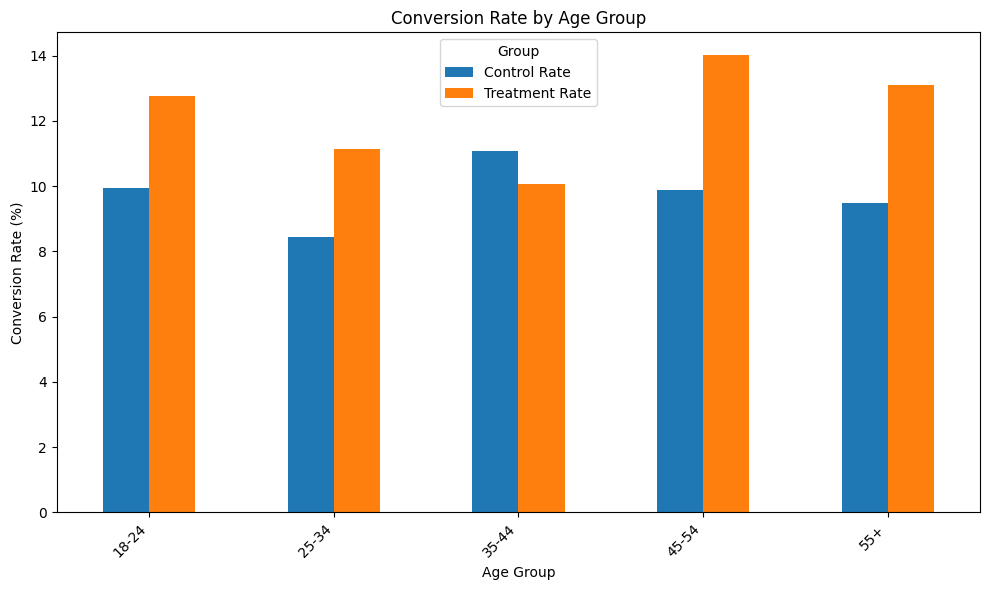

In [ ]:
age_group_pivot = (
    age_group_test_results
    .pivot_table(index="Segment", values=["Control Rate", "Treatment Rate"])
)

age_group_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Conversion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Group")
plt.tight_layout()
plt.show()

In [ ]:
correlation = df['pages_viewed'].corr(df['converted'])
print(f"Correlation between pages_viewed and converted: {correlation:.4f}")

Correlation between pages_viewed and converted: 0.0142


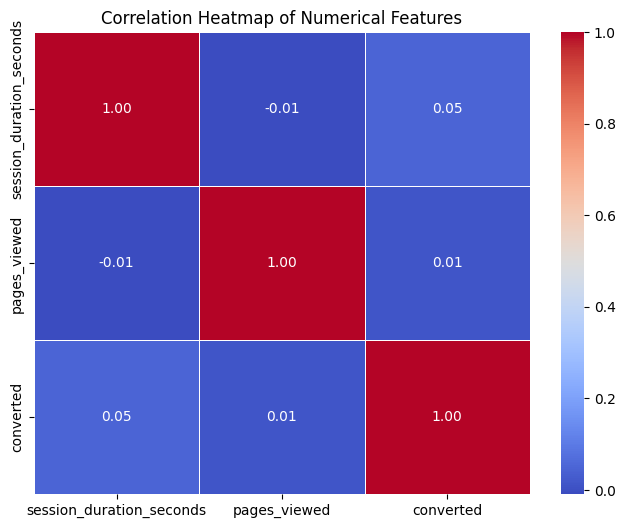

In [ ]:
import seaborn as sns

numerical_cols = ['session_duration_seconds', 'pages_viewed', 'converted']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("The difference in conversion rates is statistically significant.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that conversion rates differ.")

Reject the null hypothesis.
The difference in conversion rates is statistically significant.


In [ ]:
from statsmodels.stats.proportion import confint_proportions_2indep

control_conversions = df.loc[
        df["group"] == "Control", "converted"
].sum()

control_users = (
        df["group"] == "Control"
).sum()

treatment_conversions = df.loc[
        df["group"] == "Treatment", "converted"
].sum()

treatment_users = (
        df["group"] == "Treatment"
).sum()

ci_low, ci_high = confint_proportions_2indep(
        treatment_conversions,
            treatment_users,
                control_conversions,
                    control_users,
                        method="wald"
)

print(f"95% CI for Treatment - Control: {ci_low:.4f} to {ci_high:.4f}")

95% CI for Treatment - Control: 0.0025 to 0.0403


In [ ]:
control_rate = control_conversions / control_users
treatment_rate = treatment_conversions / treatment_users

absolute_lift = treatment_rate - control_rate
relative_lift = (absolute_lift / control_rate) * 100

results = pd.DataFrame({
        "Metric": [
                    "Control Conversion Rate",
                            "Treatment Conversion Rate",
                                    "Absolute Lift",
                                            "Relative Lift",
                                                    "Z-statistic",
                                                            "P-value",
                                                                    "CI Lower",
                                                                            "CI Upper"
        ],
            "Value": [
                        f"{control_rate:.2%}",
                                f"{treatment_rate:.2%}",
                                        f"{absolute_lift:.2%}",
                                                f"{relative_lift:.2f}%",
                                                        f"{z_stat:.4f}",
                                                                f"{p_value:.6f}",
                                                                        f"{ci_low:.4f}",
                                                                                f"{ci_high:.4f}"
            ]
})

display(results)

,Metric,Value
0,Control Conversion Rate,9.65%
1,Treatment Conversion Rate,11.79%
2,Absolute Lift,2.14%
3,Relative Lift,22.16%
4,Z-statistic,-2.2185
5,P-value,0.026518
6,CI Lower,0.0025
7,CI Upper,0.0403


In [ ]:
device_results = (
        df.groupby(["device", "group"])["converted"]
              .agg(["count", "sum", "mean"])
                    .reset_index()
)

device_results["conversion_rate"] = device_results["mean"] * 100

display(device_results)

,device,group,count,sum,mean,conversion_rate
0,Desktop,Control,575,75.0,0.130435,13.043478
1,Desktop,Treatment,631,89.0,0.141046,14.104596
2,Mobile,Control,1289,104.0,0.080683,8.068270
3,Mobile,Treatment,1277,133.0,0.104150,10.415035
4,Tablet,Control,187,19.0,0.101604,10.160428
5,Tablet,Treatment,161,22.0,0.136646,13.664596


In [ ]:
device_pivot = (
        device_results
            .pivot(index="device", columns="group", values="conversion_rate")
)

display(device_pivot)

group,Control,Treatment
device,,
Desktop,13.043478,14.104596
Mobile,8.068270,10.415035
Tablet,10.160428,13.664596


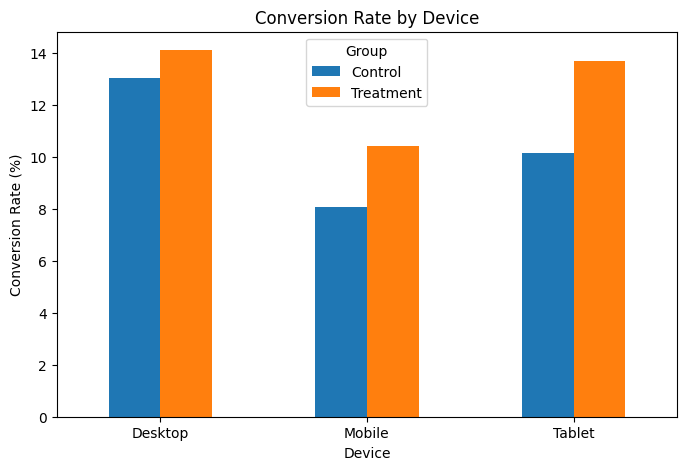

In [ ]:
device_pivot.plot(
        kind="bar",
            figsize=(8, 5)
)

plt.title("Conversion Rate by Device")
plt.xlabel("Device")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Group")
plt.show()

## A/B Test Results Summary

| Metric | Result |
| :------------------------ | :-------------------- |
| Control conversion rate | {{control_rate:.2f}}% |
| Treatment conversion rate | {{treatment_rate:.2f}}% |
| Relative lift | {{relative_lift:.2f}}% |
| p-value | {{p_value:.4f}} |
| 95% CI | {{ci_low:.4f}} to {{ci_high:.4f}} |